# Aquifer Storage and Recovery: storing freshwater in a brackish aquifer

## Overview

A well **injects** treated freshwater into a brackish aquifer, the water spreads as a radial bubble, and
later the same well **pumps it back**. Mixing at the fresh/brackish interface -- mechanical dispersion
plus molecular/thermal diffusion -- means the recovered water salts up toward the end of pumping.
`gwtransport.radial_asr` solves the **exact** radial advection-dispersion for this push--pull schedule
(no grid, no numerical dispersion) and returns the recovered concentration. Every computation here
includes molecular/thermal diffusion `D_m` (the isotropic mixing that keeps acting even when the flow is
off -- dominant for heat storage / ATES). We show two things:

1. a **single** push--pull recovers most of the stored freshwater, and
2. over **repeated** cycles a freshwater buffer builds up, so the **recovery efficiency rises each cycle**.

Chloride is conservative, so we transport the deviation from the brackish background and add it back.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.radial_asr import infiltration_to_extraction

# --- Site, well, and water chemistry (chloride, mg/L) ---
SCREEN_HEIGHT = 20.0          # m, fully-penetrating well screen
POROSITY = 0.35
WELL_RADIUS = 0.3            # m
ALPHA_L = 0.5                # m, longitudinal dispersivity
MOLECULAR_DIFFUSIVITY = 0.6  # m2/day, molecular/thermal diffusion (heat/ATES scale), included throughout
C_BRACKISH = 1200.0          # native groundwater
C_FRESH = 50.0               # injected treated water
C_POTABLE = 300.0            # usable-water threshold

GEOM = {"pore_heights": SCREEN_HEIGHT, "porosity": POROSITY, "well_radius": WELL_RADIUS,
        "longitudinal_dispersivity": ALPHA_L, "molecular_diffusivity": MOLECULAR_DIFFUSIVITY}

def push_pull():
    """One cycle: inject 1000 m3/day for 90 days (90,000 m3 stored), then recover 800 m3/day for 120 days."""
    return [1000.0] * 90 + [-800.0] * 120

INJECTED = 1000.0 * 90  # m3 of freshwater stored per cycle

# n_quad is modest: with D_m > 0 the kernel is a per-node ODE, so the resident-profile quadrature is the cost.
N_QUAD = 40

## 1. A single push--pull recovers most of the stored water

Inject 90,000 m³ of freshwater, then pump back. With **no quality threshold** -- recover everything that
comes up -- the chloride mass balance shows most of the stored freshwater returns; what is lost has
diffused beyond the recovery volume. The recovered water stays fresh, then salts up near the end as the
mixed edge of the bubble is drawn in.

recovered 87% of the injected freshwater (no quality threshold)


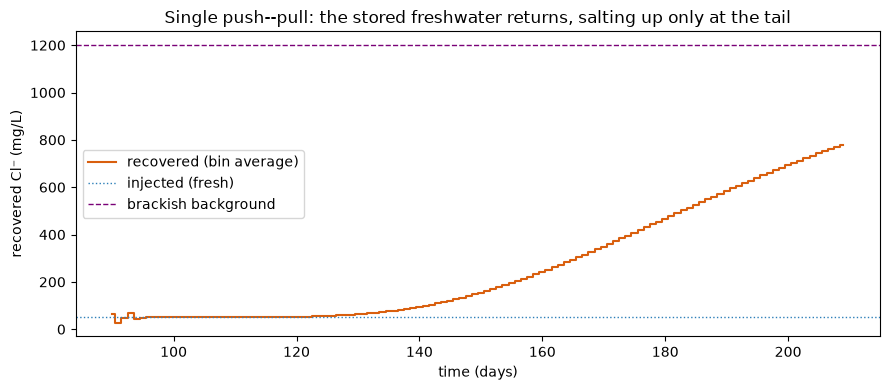

In [2]:
flow = np.array(push_pull())
tedges = pd.date_range("2021-01-01", periods=len(flow) + 1, freq="D")
cin = np.where(flow > 0, C_FRESH, C_BRACKISH)
t, ext = np.arange(len(flow)), flow < 0

cout = infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges, background=C_BRACKISH, n_quad=N_QUAD, **GEOM,
)

# Recovery with no threshold = recovered freshwater (chloride deficit) / injected freshwater.
recovered = np.sum((-flow[ext]) * (C_BRACKISH - cout[ext])) / np.sum(flow[flow > 0] * (C_BRACKISH - cin[flow > 0]))
print(f"recovered {100 * recovered:.0f}% of the injected freshwater (no quality threshold)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(t[ext], cout[ext], where="mid", lw=1.5, color="#d95f0e", label="recovered (bin average)")
ax.axhline(C_FRESH, color="#2c7fb8", ls=":", lw=1, label="injected (fresh)")
ax.axhline(C_BRACKISH, color="#7a0177", ls="--", lw=1, label="brackish background")
ax.set_xlabel("time (days)"); ax.set_ylabel("recovered Cl⁻ (mg/L)")
ax.set_title("Single push--pull: the stored freshwater returns, salting up only at the tail")
ax.legend(); fig.tight_layout(); plt.show()

## 2. Repeated cycles build a buffer: recovery efficiency rises

Run the same cycle three times and apply the potable threshold (300 mg/L). The **recovery efficiency**
is the fraction of the injected volume recovered below the threshold. Freshwater left behind each cycle
freshens the aquifer around the well, so each cycle starts fresher and recovers a little more -- the
buffer effect real ASR schemes rely on to ramp up over their first years. Cycles are just the sign
pattern of `flow`; the engine composes them automatically.

cycle 1: recovery efficiency 68%
cycle 2: recovery efficiency 73%
cycle 3: recovery efficiency 76%


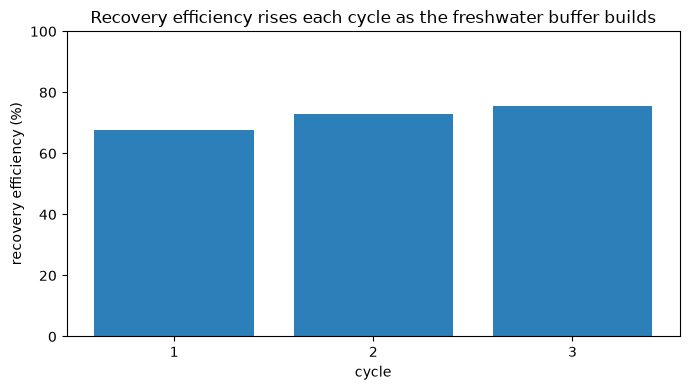

In [3]:
n_cycles = 3
flow = np.array(push_pull() * n_cycles)
tedges = pd.date_range("2021-01-01", periods=len(flow) + 1, freq="D")
cin = np.where(flow > 0, C_FRESH, C_BRACKISH)

cout = infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges, background=C_BRACKISH, n_quad=N_QUAD, **GEOM,
)

cyc = len(push_pull())
re = []
for k in range(n_cycles):
    f, c = flow[k * cyc:(k + 1) * cyc], cout[k * cyc:(k + 1) * cyc]
    e = f < 0
    re.append(np.sum((-f[e]) * (c[e] < C_POTABLE)) / INJECTED)
for k, r in enumerate(re, 1):
    print(f"cycle {k}: recovery efficiency {100 * r:.0f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, n_cycles + 1), [100 * r for r in re], color="#2c7fb8")
ax.set_xlabel("cycle"); ax.set_ylabel("recovery efficiency (%)")
ax.set_xticks(range(1, n_cycles + 1)); ax.set_ylim(0, 100)
ax.set_title("Recovery efficiency rises each cycle as the freshwater buffer builds")
fig.tight_layout(); plt.show()

## Takeaways

- **A single push--pull recovers most of the stored freshwater** -- radial advection is reversible and
  only dispersion and diffusion smear the interface, so without a quality cutoff most of the mass comes
  back (it just salts up at the tail).
- **Recovery efficiency rises over cycles** -- freshwater left behind buffers the next cycle, the physical
  reason real ASR schemes improve over their first few years. The engine captures this exactly from the
  flow schedule alone, with molecular/thermal diffusion (`D_m`) carried throughout.

## References

- Tang, D. H., & Babu, D. K. (1979). Analytical solution of a velocity dependent dispersion problem.
  *Water Resources Research*, 15(6), 1471-1478. — the radial mechanical-dispersion (`D = alpha_L |u|`)
  injection solution in Airy functions.
- Aichi, M., & Akitaya, K. (2018). Analytical solution for a radial advection-dispersion equation
  including both mechanical dispersion and molecular diffusion ... from a well. *Hydrological Research
  Letters*, 12(3), 23-27. — the `D = alpha_L |u| + D_m` injection kernel under the same flux boundary.

These treat a single injection; the extraction dual and the multi-cycle push--pull composition shown here
are built on top of them.